# Experiments on the ETH-USD dataset with returns

In [1]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [2]:
from src.models import (
    LSTMForecaster, 
    MLPForecaster, 
    LinearForecaster, 
    NaiveGaussian, 
    NaiveBootstrap, 
    TransfomerForecaster, 
    GPForecaster,
)
import torch
import numpy as np
import matplotlib.pyplot as plt
from eth_utils import plot_forecast, print_metrics
import pandas as pd
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Download data

In [3]:
binance_ethusd_2024 = pd.read_csv('../data/raw/Binance_ETHUSDT_2024_minute.csv', skiprows=1)
binance_ethusd_2024.Date = pd.to_datetime(binance_ethusd_2024.Date)
binance_ethusd_2024 = binance_ethusd_2024.sort_values(by='Date')
binance_ethusd_2024 = binance_ethusd_2024.set_index('Date')
binance_ethusd_2024 = binance_ethusd_2024[['High', 'Low']]
binance_ethusd_2024['high_return'] = np.log(binance_ethusd_2024.High/binance_ethusd_2024.High.shift(1))
binance_ethusd_2024['low_return'] = np.log(binance_ethusd_2024.Low/binance_ethusd_2024.Low.shift(1))
binance_ethusd_2024.head()

,High,Low,high_return,low_return
Date,,,,
2024-01-01 00:00:00,2282.94,2281.27,NaN,NaN
2024-01-01 00:01:00,2283.97,2282.20,0.000451,0.000408
2024-01-01 00:02:00,2284.60,2283.80,0.000276,0.000701
2024-01-01 00:03:00,2286.43,2284.38,0.000801,0.000254
2024-01-01 00:04:00,2287.84,2286.37,0.000616,0.000871


In [4]:
target = binance_ethusd_2024[['high_return', 'low_return']].values[1:]
l = len(target)
split = 0.7

In [5]:
scaler = StandardScaler()
target[:int(l*split)] = scaler.fit_transform(target[:int(l*split)])
target[int(l*split):] = scaler.transform(target[int(l*split):])

In [6]:
target = torch.tensor(target, dtype=torch.float32)
train_target = target[:int(l*split)]
test_target = target[int(l*split):]

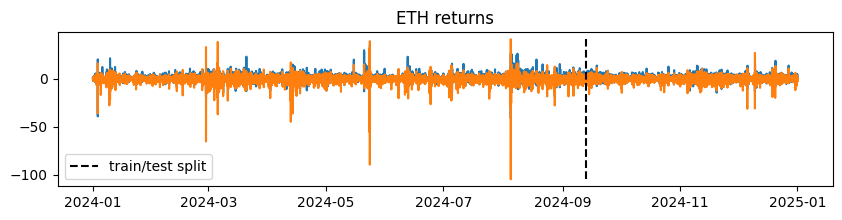

In [7]:
min_, max_ = target.min(), target.max()
plt.figure(figsize=(10, 2))
plt.plot(binance_ethusd_2024.index[1:], target)
plt.vlines(binance_ethusd_2024.index[int(l*split) + 1], min_, max_, linestyles='dashed', color='black', label='train/test split')
plt.title('ETH returns')
plt.legend()
plt.show()

In [52]:
model = LSTMForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/lstm_returns_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=5,
    num_layers=1,
    lr=0.0001, 
    hidden_dim=128,
)

In [53]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

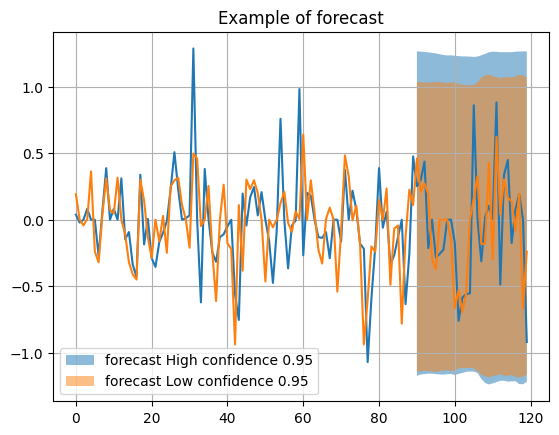

PICP: 0.9579
ECE: 0.0079
CRPS: 3.6903


In [54]:
plot_forecast(model, test_dataset, idx=4)
lstm_metrics = print_metrics(model, test_dataset)

In [62]:
model = MLPForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/mlp_returns_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01, 
    num_layers=1,
    hidden_dim=128,
)
model

MLPForecaster(
  (model): MLPModule(
    (mlp): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=4, bias=True)
    )
  )
)

In [63]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

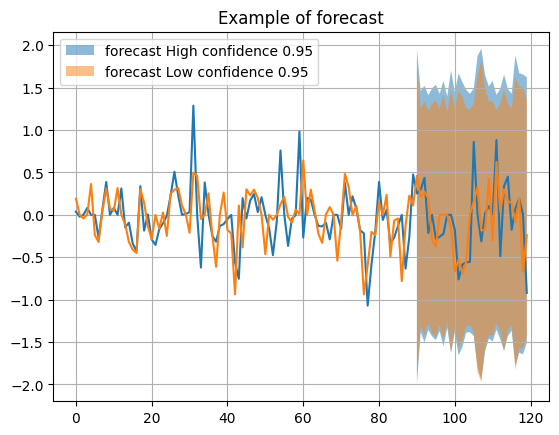

PICP: 0.9462
ECE: 0.0038
CRPS: 3.5749


In [64]:
plot_forecast(model, test_dataset, idx=4)
mlp_metrics = print_metrics(model, test_dataset)

## Linear

In [83]:
model = LinearForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/linear_returns_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01,
)
model

LinearForecaster(
  (model): LinearModule(
    (linear): Linear(in_features=2, out_features=4, bias=True)
  )
)

In [84]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

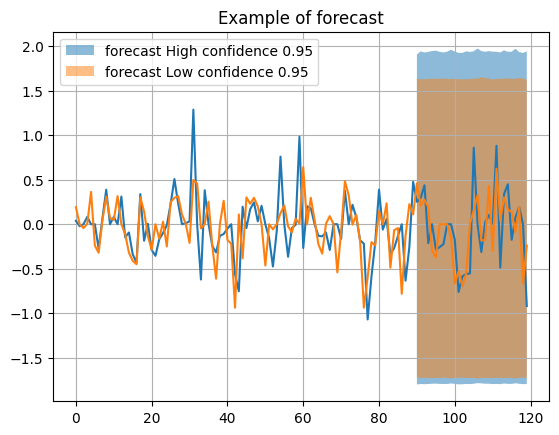

PICP: 0.9411
ECE: 0.0089
CRPS: 3.5128


In [85]:
plot_forecast(model, test_dataset, idx=4)
linear_metrics = print_metrics(model, test_dataset)

## Naive Gaussian

In [86]:
model = NaiveGaussian(
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
)
model

NaiveGaussian()

In [87]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

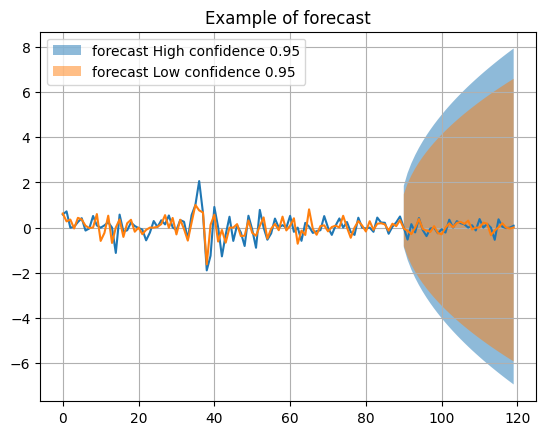

PICP: 0.9955
ECE: 0.0455
CRPS: 15.4696


In [88]:
plot_forecast(model, test_dataset, idx=4)
naive_gaussian_metrics = print_metrics(model, test_dataset)

## Naive Bootstrap

In [89]:
model = NaiveBootstrap(
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    num_samples=1000,
)
model

NaiveBootstrap()

In [92]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

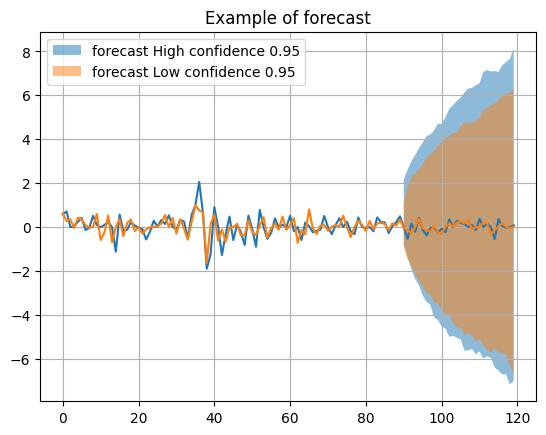

  0%|          | 0/158 [00:00<?, ?it/s]

PICP: 0.9951
ECE: 0.0451
CRPS: 15.4946


In [93]:
plot_forecast(model, test_dataset, idx=4)
naive_bootstrap_metrics = print_metrics(model, test_dataset, batch_size=1000)

## Transformer

In [190]:
model = TransfomerForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/transformer_returns_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=5,
    lr=0.001,
    num_layers=2,
    d_model=64,
    num_heads=1,
    dim_feedforward=128,
    dropout=0.,
)
model

TransfomerForecaster(
  (model): TransformerEncoderModule(
    (input_projection): Linear(in_features=2, out_features=64, bias=True)
    (positional_encoding): PositionalEncoding()
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (output_projection): Linear(in_features=64, out_features=4, bias=True)
 

In [191]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

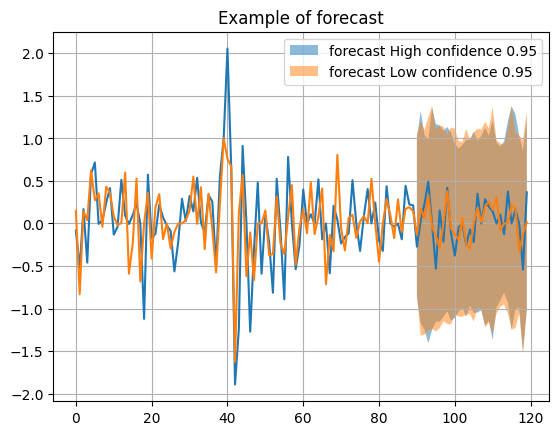

PICP: 0.9351
ECE: 0.0149
CRPS: 3.2590


In [192]:
plot_forecast(model, test_dataset, idx=0)
transformer_metrics = print_metrics(model, test_dataset)

## Gaussian process

In [197]:
model = GPForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/gp_returns_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01,
    num_inducing=100,
)
model

GPForecaster(
  (model): GPModule(
    (mean_linear): Linear(in_features=100, out_features=2, bias=True)
    (var_linear): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [198]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

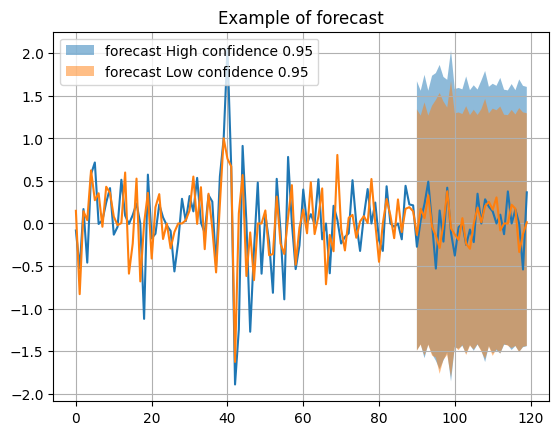

PICP: 0.9478
ECE: 0.0022
CRPS: 3.6207


In [199]:
plot_forecast(model, test_dataset, idx=0)
gp_metrics = print_metrics(model, test_dataset)

## Results

In [200]:
pd.DataFrame({
    'LSTM': lstm_metrics,
    'MLP': mlp_metrics,
    'Linear': linear_metrics,
    'Naive Gaussian': naive_gaussian_metrics,
    'Naive Bootstrap': naive_bootstrap_metrics,
    'Transformer': transformer_metrics,
    'Gaussian process': gp_metrics,
}).T.round(4)

,picp,ece,crps
LSTM,0.9462,0.0038,3.5749
MLP,0.9462,0.0038,3.5749
Linear,0.9411,0.0089,3.5128
Naive Gaussian,0.9955,0.0455,15.4696
Naive Bootstrap,0.9951,0.0451,15.4946
Transformer,0.9351,0.0149,3.2590
Gaussian process,0.9478,0.0022,3.6207


## Visualization of forecast in prices

In [168]:
model = LinearForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/linear_returns_checkpoint.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    step_size=30,
    batch_size=32,
    num_epochs=10,
    lr=0.01,
)
model

LinearForecaster(
  (model): LinearModule(
    (linear): Linear(in_features=2, out_features=4, bias=True)
  )
)

In [169]:
input_seq, output_seq = test_dataset[0]
output_seq = output_seq[-model.output_len:]
pred_seq = model.predict(input_seq[None, :, :])
pred_seq = pred_seq[0]
input_seq, output_seq, pred_seq = input_seq.numpy(), output_seq.numpy(), pred_seq.numpy()
input_seq, output_seq, pred_seq[:, :, 0], pred_seq[:, :, 1] = (
    scaler.inverse_transform(input_seq), 
    scaler.inverse_transform(output_seq), 
    scaler.inverse_transform(pred_seq[:, :, 0]),
    scaler.inverse_transform(pred_seq[:, :, 1]),
)
input_seq, output_seq, pred_seq = np.exp(input_seq), np.exp(output_seq), np.exp(pred_seq)
input_seq.shape, output_seq.shape, pred_seq.shape

((90, 2), (30, 2), (30, 2, 2))

In [170]:
starting_price = binance_ethusd_2024.iloc[int(l*split) + 1][['High', 'Low']].values
starting_price = starting_price[None, :]
starting_price

array([[2353.45, 2352.  ]])

In [175]:
full_price = np.concat([starting_price, input_seq, output_seq]).cumprod(axis=0)
full_price.shape

(121, 2)

In [180]:
lbound_price = np.concat([starting_price, input_seq, pred_seq[:, :, 0]]).cumprod(axis=0)
ubound_price = np.concat([starting_price, input_seq, pred_seq[:, :, 1]]).cumprod(axis=0)
lbound_price = lbound_price[-model.output_len:]
ubound_price = ubound_price[-model.output_len:]
lbound_price.shape, ubound_price.shape

((30, 2), (30, 2))

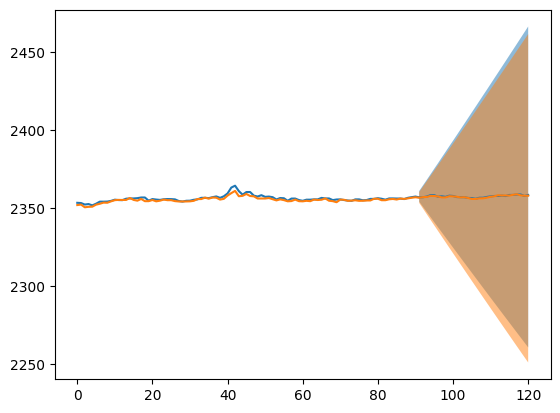

In [185]:
plt.plot(full_price);
plt.fill_between(
    range(len(full_price)-model.output_len, len(full_price)), 
    lbound_price[:, 0], ubound_price[:, 0], 
    alpha=0.5
)
plt.fill_between(
    range(len(full_price)-model.output_len, len(full_price)), 
    lbound_price[:, 1], ubound_price[:, 1],
    alpha=0.5
);